In [1]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.7 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import zipfile
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt

import ultralytics
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ZIP_PATH="/content/drive/MyDrive/Smart_Warehouse_Inventory_Project.zip"

EXTRACT_PATH="/content"

with zipfile.ZipFile(ZIP_PATH,"r") as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Project Extracted Successfully")

Project Extracted Successfully


In [5]:
PROJECT_ROOT=Path("/content/Smart_Warehouse_Inventory_Project")

DATASET_PATH=PROJECT_ROOT/"dataset"

DATA_YAML=DATASET_PATH/"data.yaml"

MODEL_PATH=Path("/content/drive/MyDrive/YOLO_Training_imgsz640/warehouse_inventory_imgsz640/weights_imgsz_640/best_640.pt")

RESULTS_FOLDER=Path("/content/drive/MyDrive/YOLO_Training_imgsz640/warehouse_inventory_imgsz640")
print(PROJECT_ROOT.exists())
print(DATASET_PATH.exists())
print(DATA_YAML.exists())
print(MODEL_PATH.exists())
print(RESULTS_FOLDER.exists())

True
True
True
True
True


In [6]:
# Load MOdel
model=YOLO(MODEL_PATH)

print("Model Loaded Successfully")

Model Loaded Successfully


In [7]:
# Validation
metrics=model.val(
    data=str(DATA_YAML)
)

print("Validation Completed Successfully")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 3,010,523 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1731.0±768.3 MB/s, size: 371.9 KB)
val: Scanning /content/Smart_Warehouse_Inventory_Project/dataset/labels/val... 1125 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1125/1125 828.6it/s 1.4s
val: New cache created: /content/Smart_Warehouse_Inventory_Project/dataset/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 71/71 5.5s/it 6:27
                   all       1125      13873      0.697      0.538      0.614      0.534
                   box       1038       1038      0.703      0.647      0.714      0.623
                 crate        218        218      0.646       0.26      0.397       0.29
                barrel        206        206      0.603      0.325      0.416      0.331
              

In [8]:
# Model Evaluation

print(f"mAP@0.5        : {metrics.box.map50:.4f}")

print(f"mAP@0.5:0.95   : {metrics.box.map:.4f}")

print(f"Precision      : {metrics.box.mp:.4f}")

print(f"Recall         : {metrics.box.mr:.4f}")

mAP@0.5        : 0.6145
mAP@0.5:0.95   : 0.5342
Precision      : 0.6968
Recall         : 0.5381


In [10]:
# Read Training Results

results_csv=RESULTS_FOLDER/"results_640.csv"

results_df=pd.read_csv(results_csv)

results_df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,147.711,1.73228,4.06401,1.64964,0.36126,0.10932,0.05901,0.04106,1.47438,3.40676,1.44312,0.000115,0.000115,0.000115
1,2,286.141,1.24858,2.99031,1.31987,0.45564,0.16153,0.12838,0.09416,1.14258,2.75504,1.20643,0.000218,0.000218,0.000218
2,3,424.981,1.06059,2.47442,1.19181,0.47298,0.24057,0.19986,0.15052,1.00104,2.30634,1.10802,0.000310,0.000310,0.000310
3,4,566.114,0.95828,2.17464,1.12244,0.40509,0.28395,0.26863,0.20662,0.87444,2.00832,1.03386,0.000294,0.000294,0.000294
4,5,705.667,0.90584,1.98777,1.08878,0.50494,0.34096,0.32692,0.25958,0.80306,1.78985,0.98833,0.000277,0.000277,0.000277


In [11]:
# Display last epoch
results_df.tail(1)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
19,20,2833.63,0.53671,0.94739,0.91572,0.69604,0.53854,0.61475,0.5335,0.50088,0.90877,0.8262,0.000021,0.000021,0.000021


In [12]:
# Best epoch
best_epoch=results_df["metrics/mAP50(B)"].idxmax()

print("Best Epoch :",best_epoch)

print()

print(results_df.loc[best_epoch])

Best Epoch : 19

epoch                     20.000000
time                    2833.630000
train/box_loss             0.536710
train/cls_loss             0.947390
train/dfl_loss             0.915720
metrics/precision(B)       0.696040
metrics/recall(B)          0.538540
metrics/mAP50(B)           0.614750
metrics/mAP50-95(B)        0.533500
val/box_loss               0.500880
val/cls_loss               0.908770
val/dfl_loss               0.826200
lr/pg0                     0.000021
lr/pg1                     0.000021
lr/pg2                     0.000021
Name: 19, dtype: float64


In [13]:
from pathlib import Path

for file in sorted(RESULTS_FOLDER.iterdir()):
    print(file.name)



BoxF1_curve_640.png
BoxPR_curve_640.png
BoxP_curve_640.png
BoxR_curve_640.png
confusion_matrix_640.png
confusion_matrix_normalized_640.png
imgsz640_args.yaml
labels_640.jpg
results_640.csv
results_640.png
train_batch0_640.jpg
train_batch1_640.jpg
train_batch2910_640.jpg
train_batch2911_640.jpg
train_batch2912_640.jpg
train_batch2_640.jpg
val_batch0_labels_640.jpg
val_batch0_pred_640.jpg
val_batch1_labels_640.jpg
val_batch1_pred_640.jpg
val_batch2_labels_640.jpg
val_batch2_pred_640.jpg
weights_imgsz_640


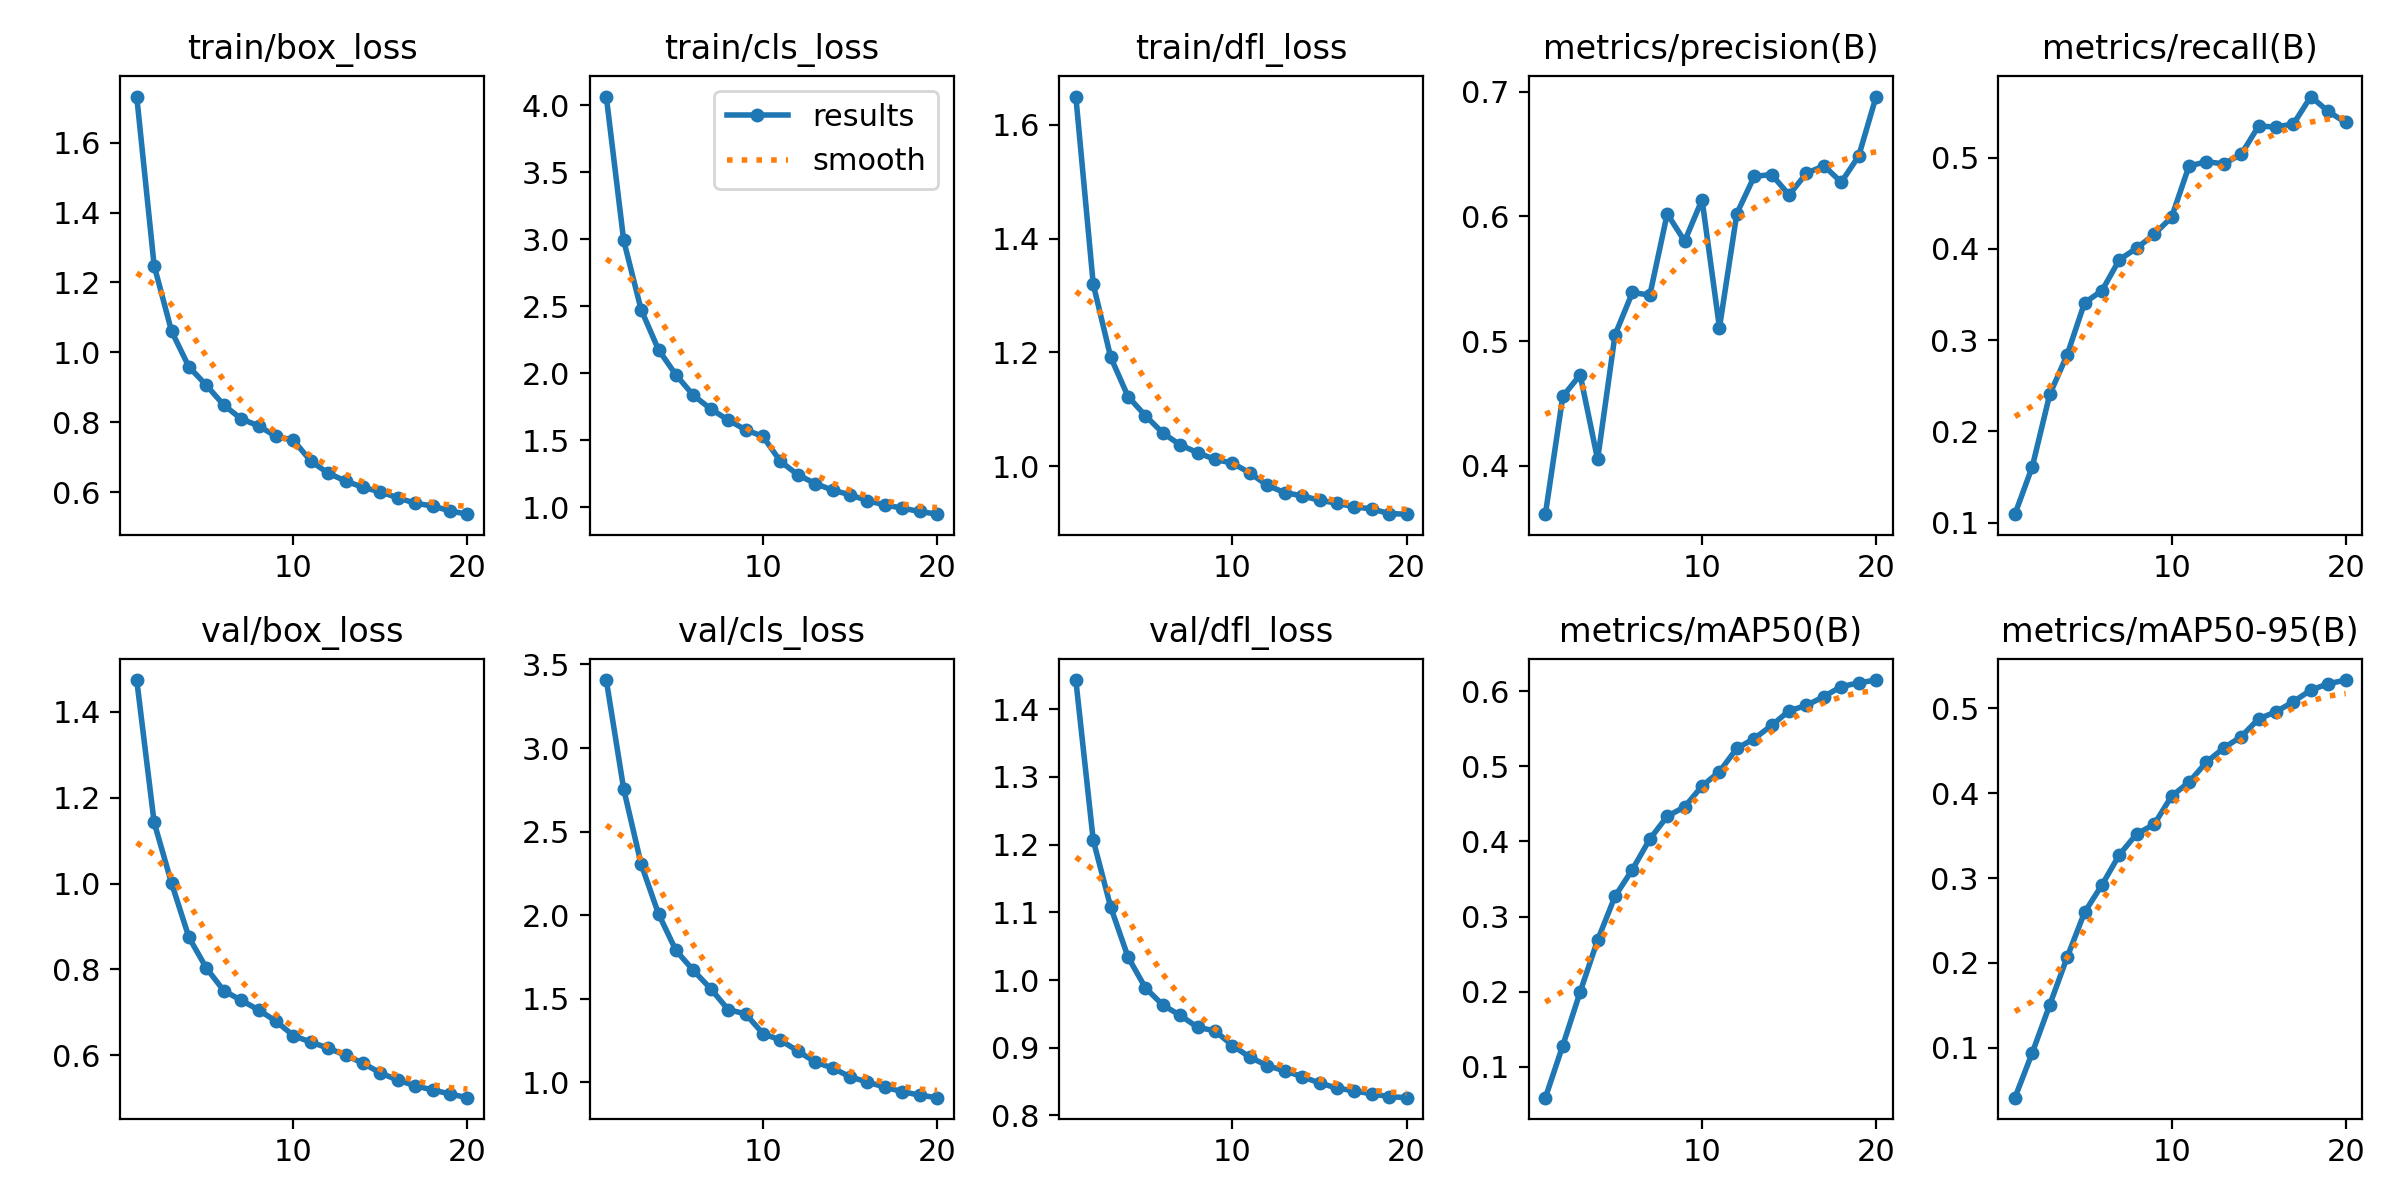

In [15]:
# Display Training Curves
from IPython.display import Image

Image(filename=str(RESULTS_FOLDER/"results_640.png"))

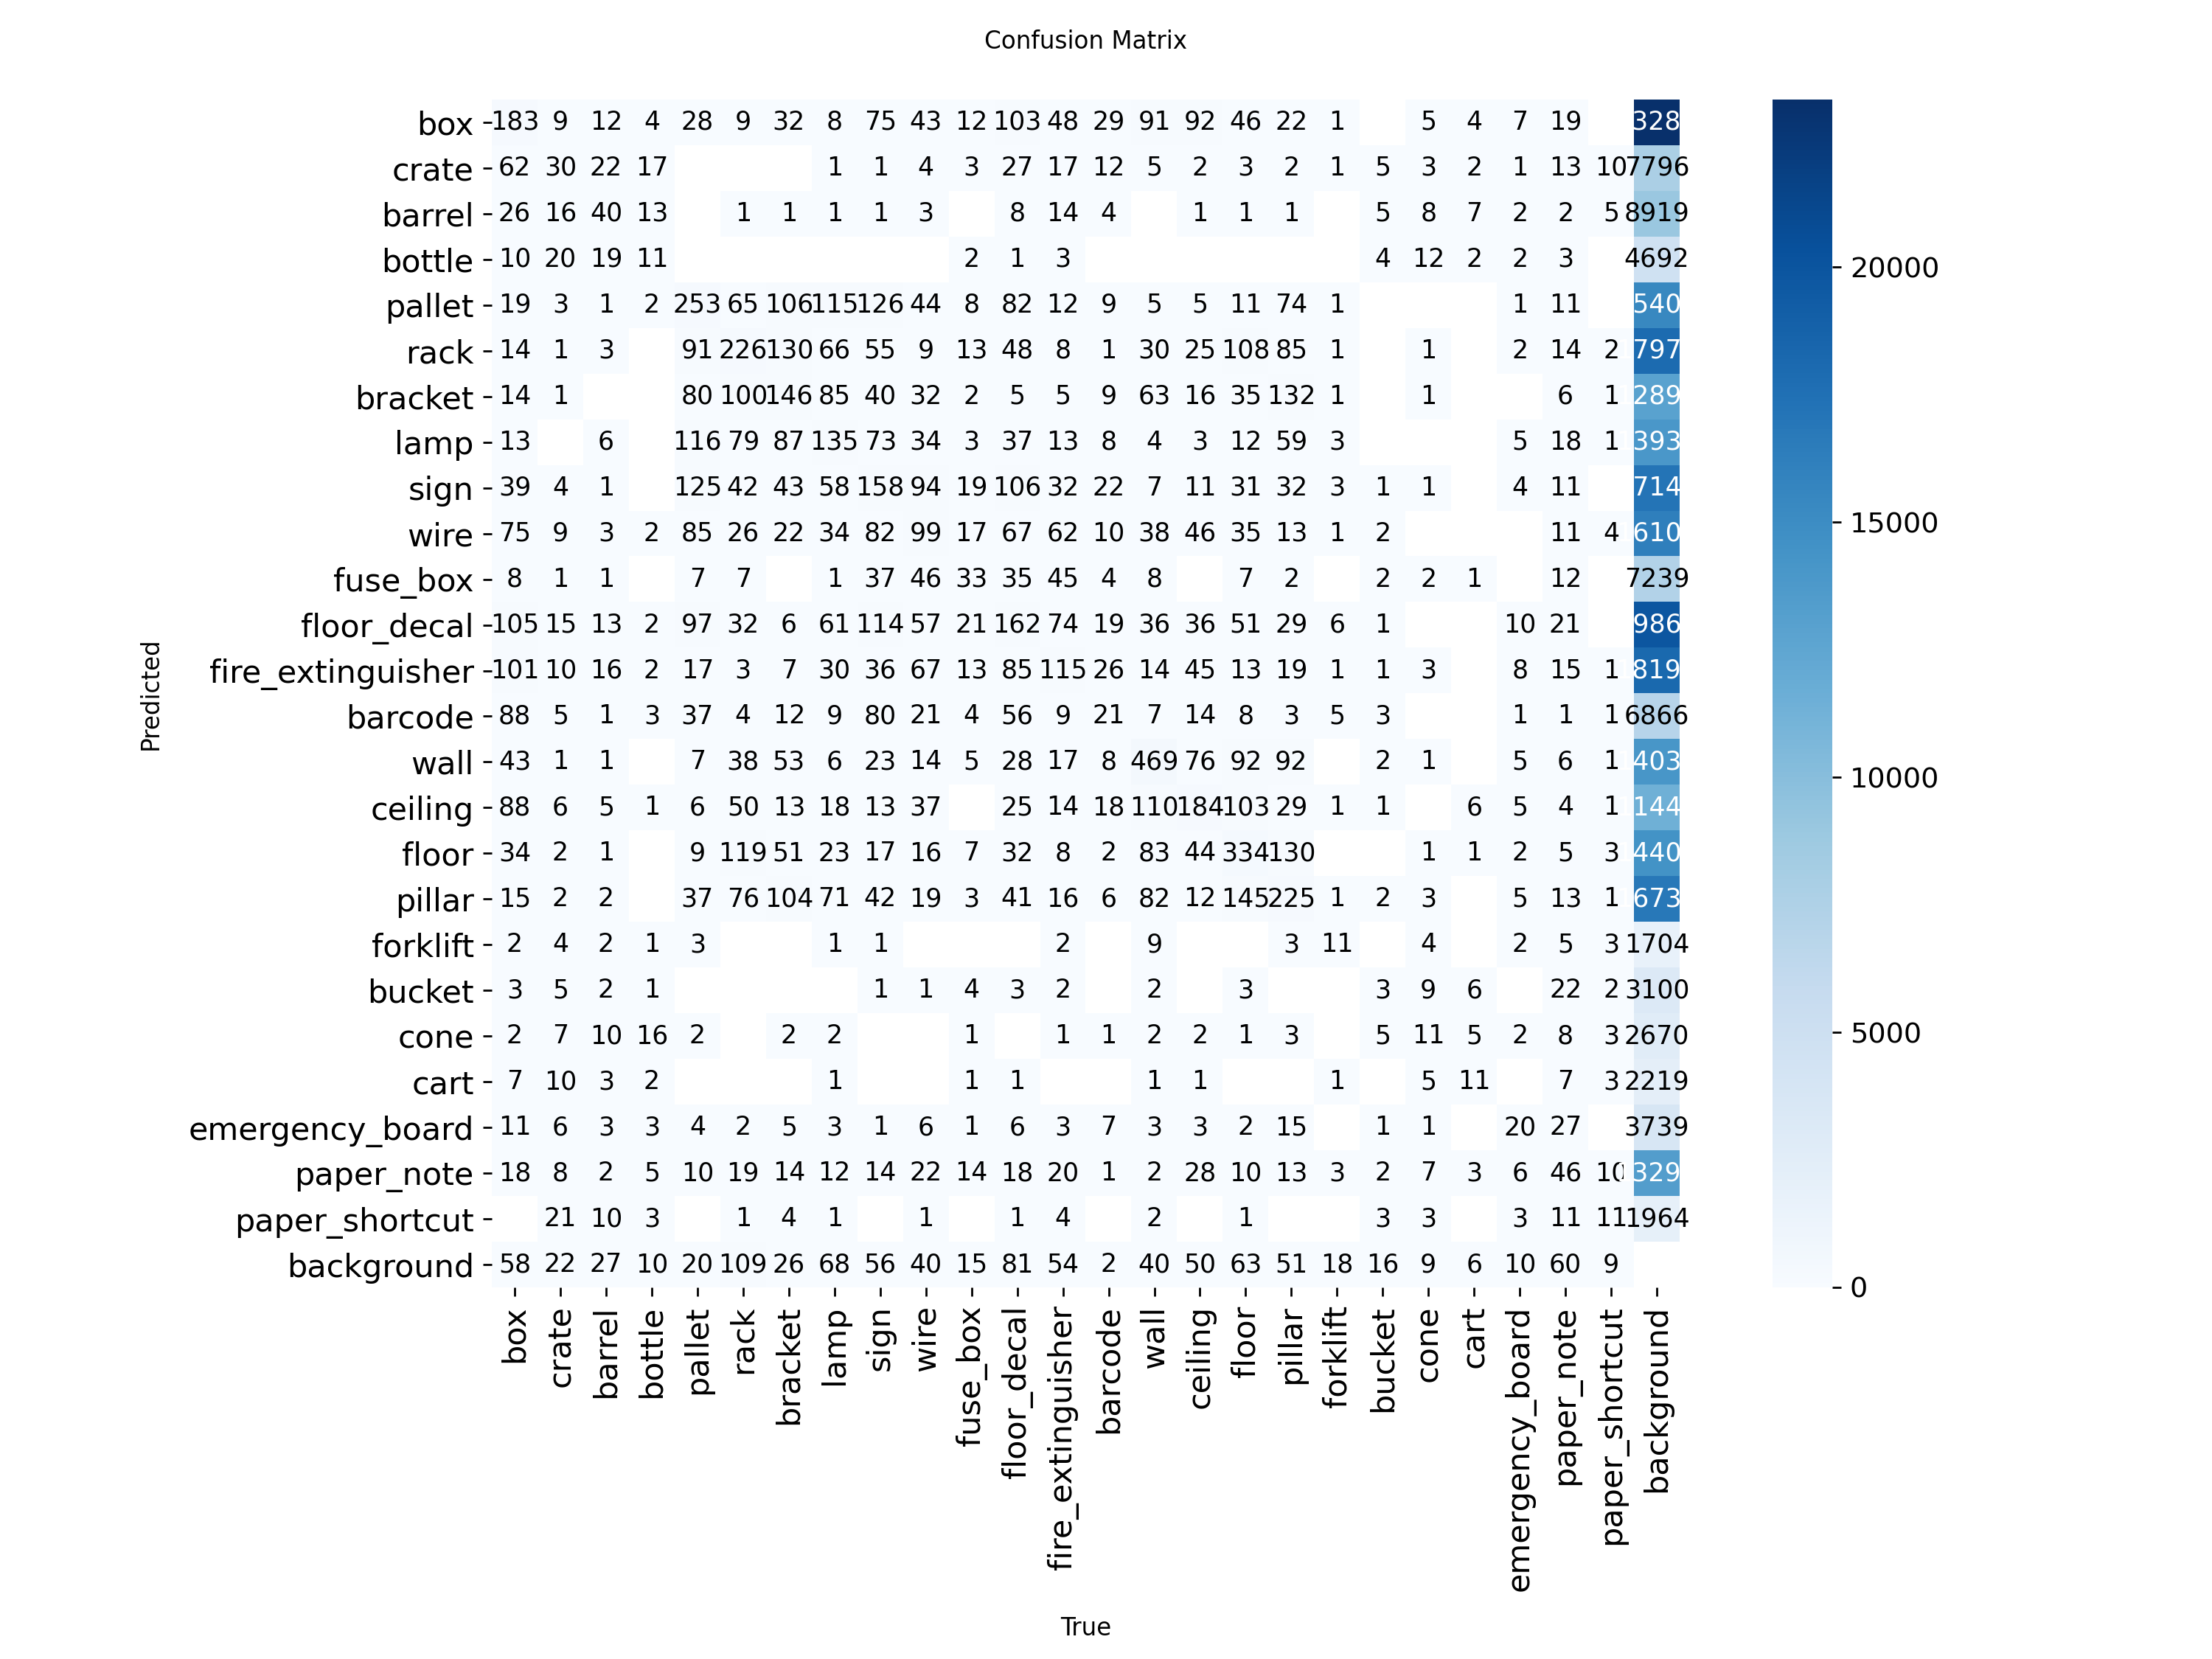

In [17]:
# Confusion Matrix

Image(filename=str(RESULTS_FOLDER/"confusion_matrix_640.png"))



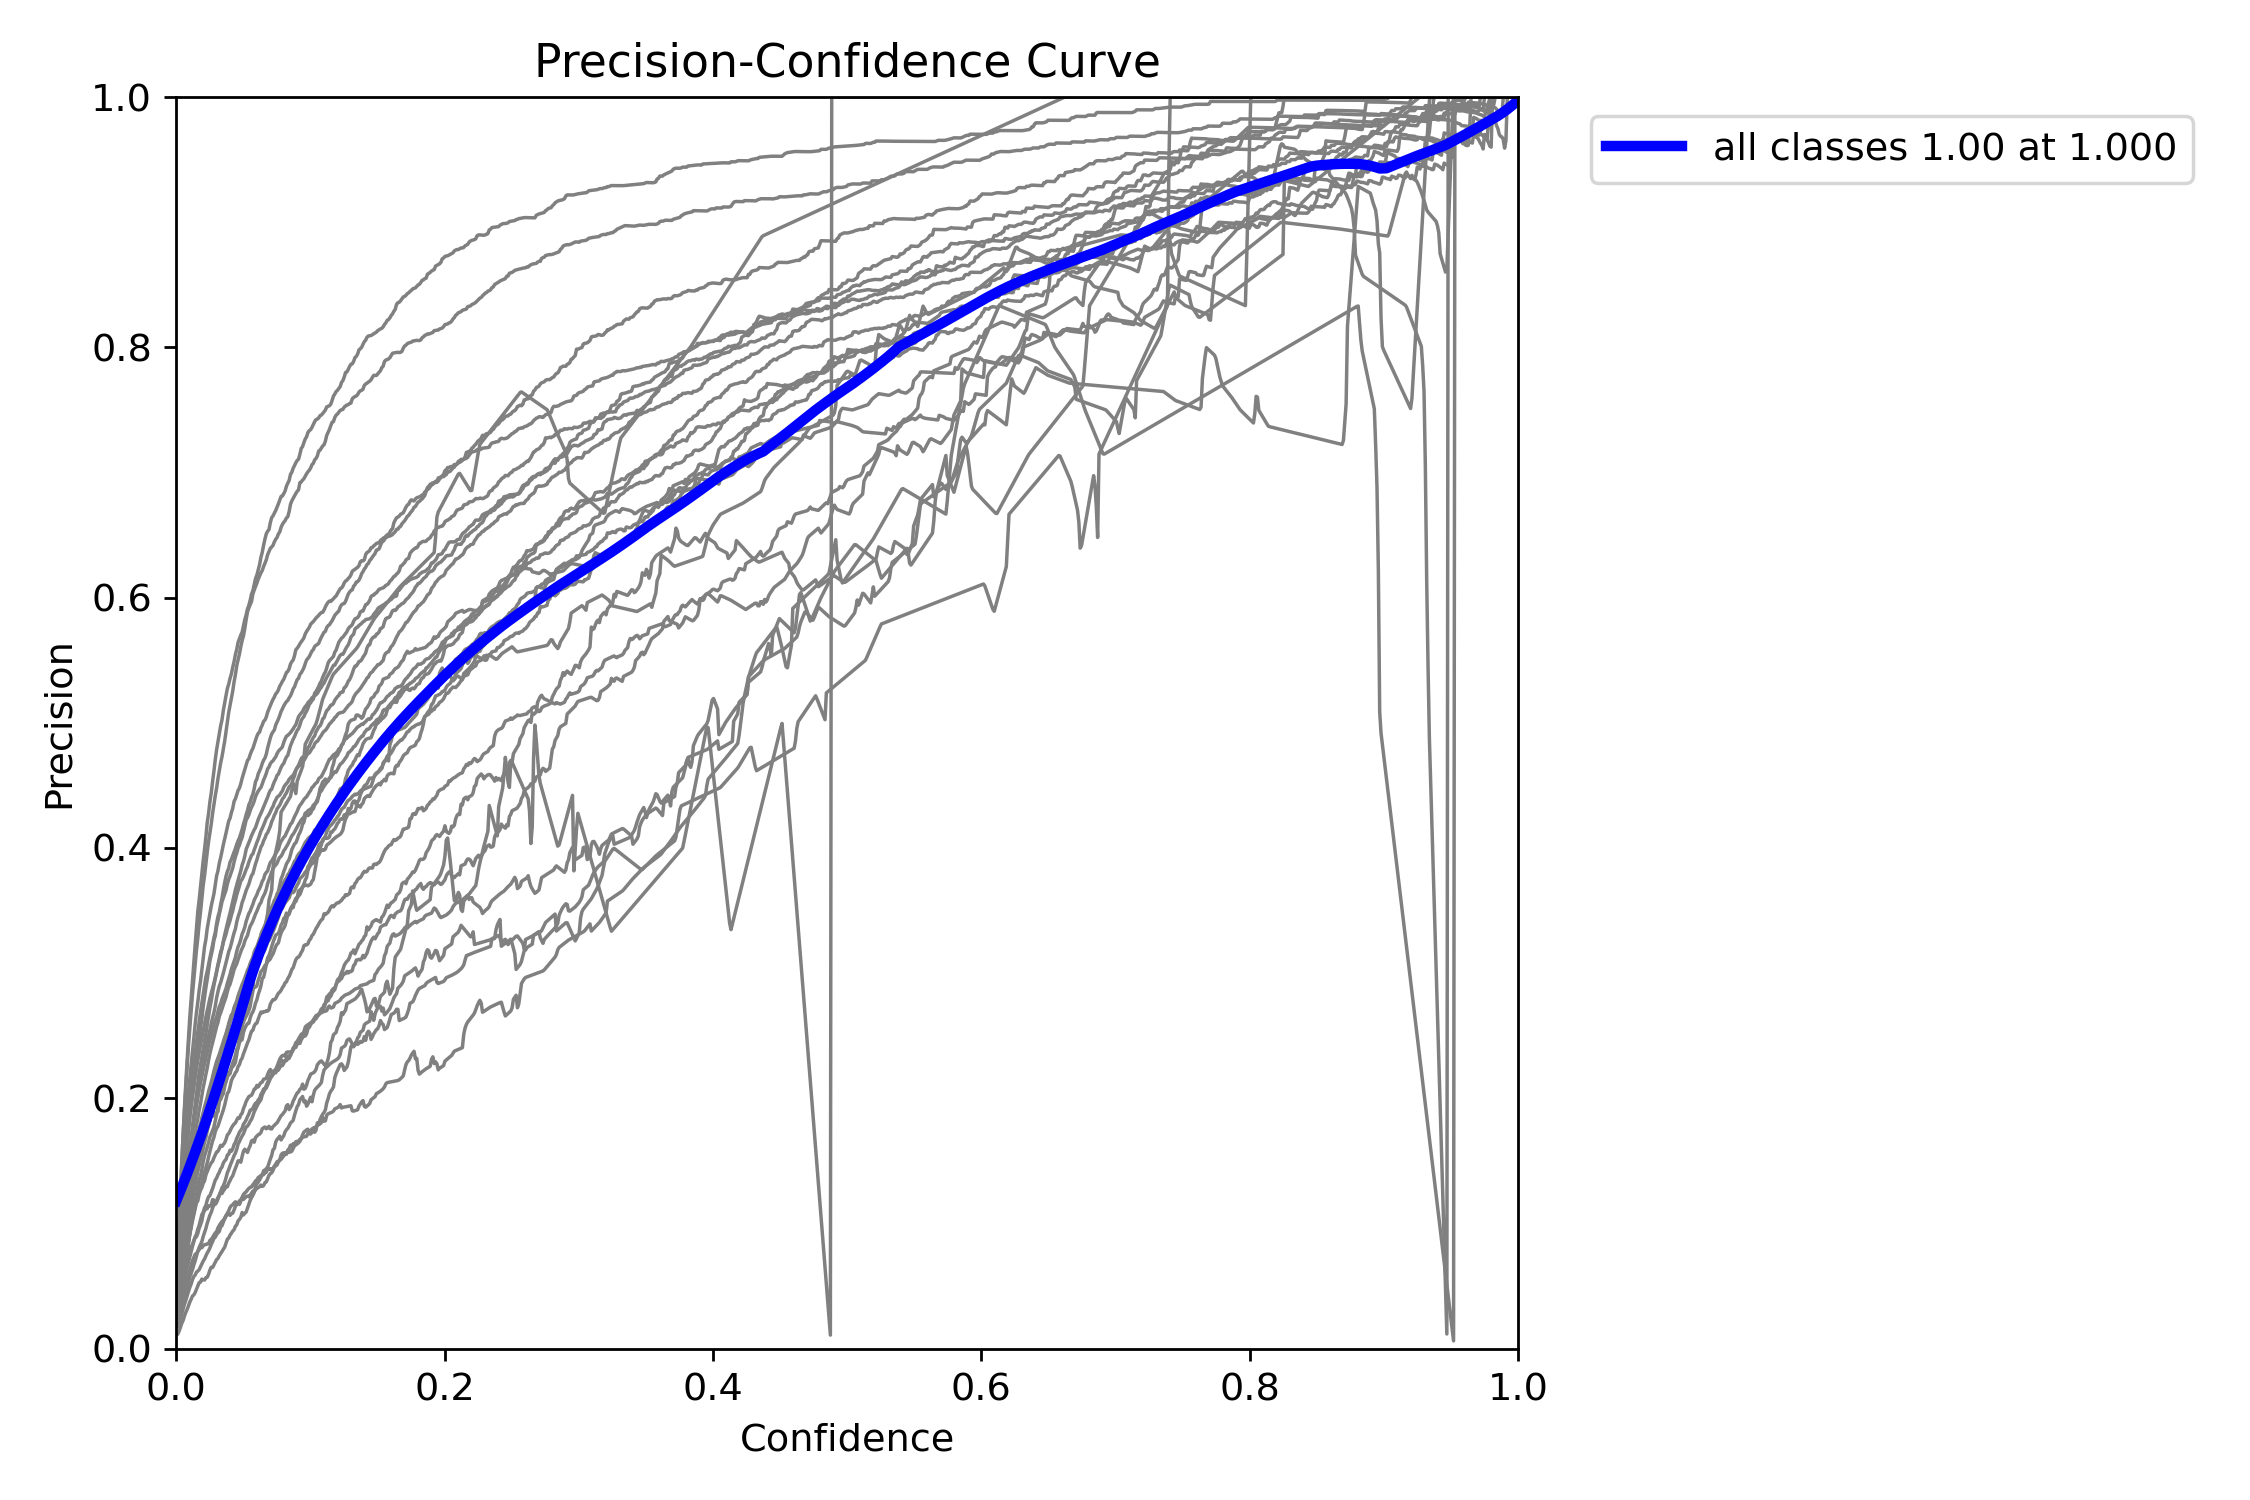

In [18]:
# Precision Curve
Image(filename=str(RESULTS_FOLDER/"BoxP_curve_640.png"))

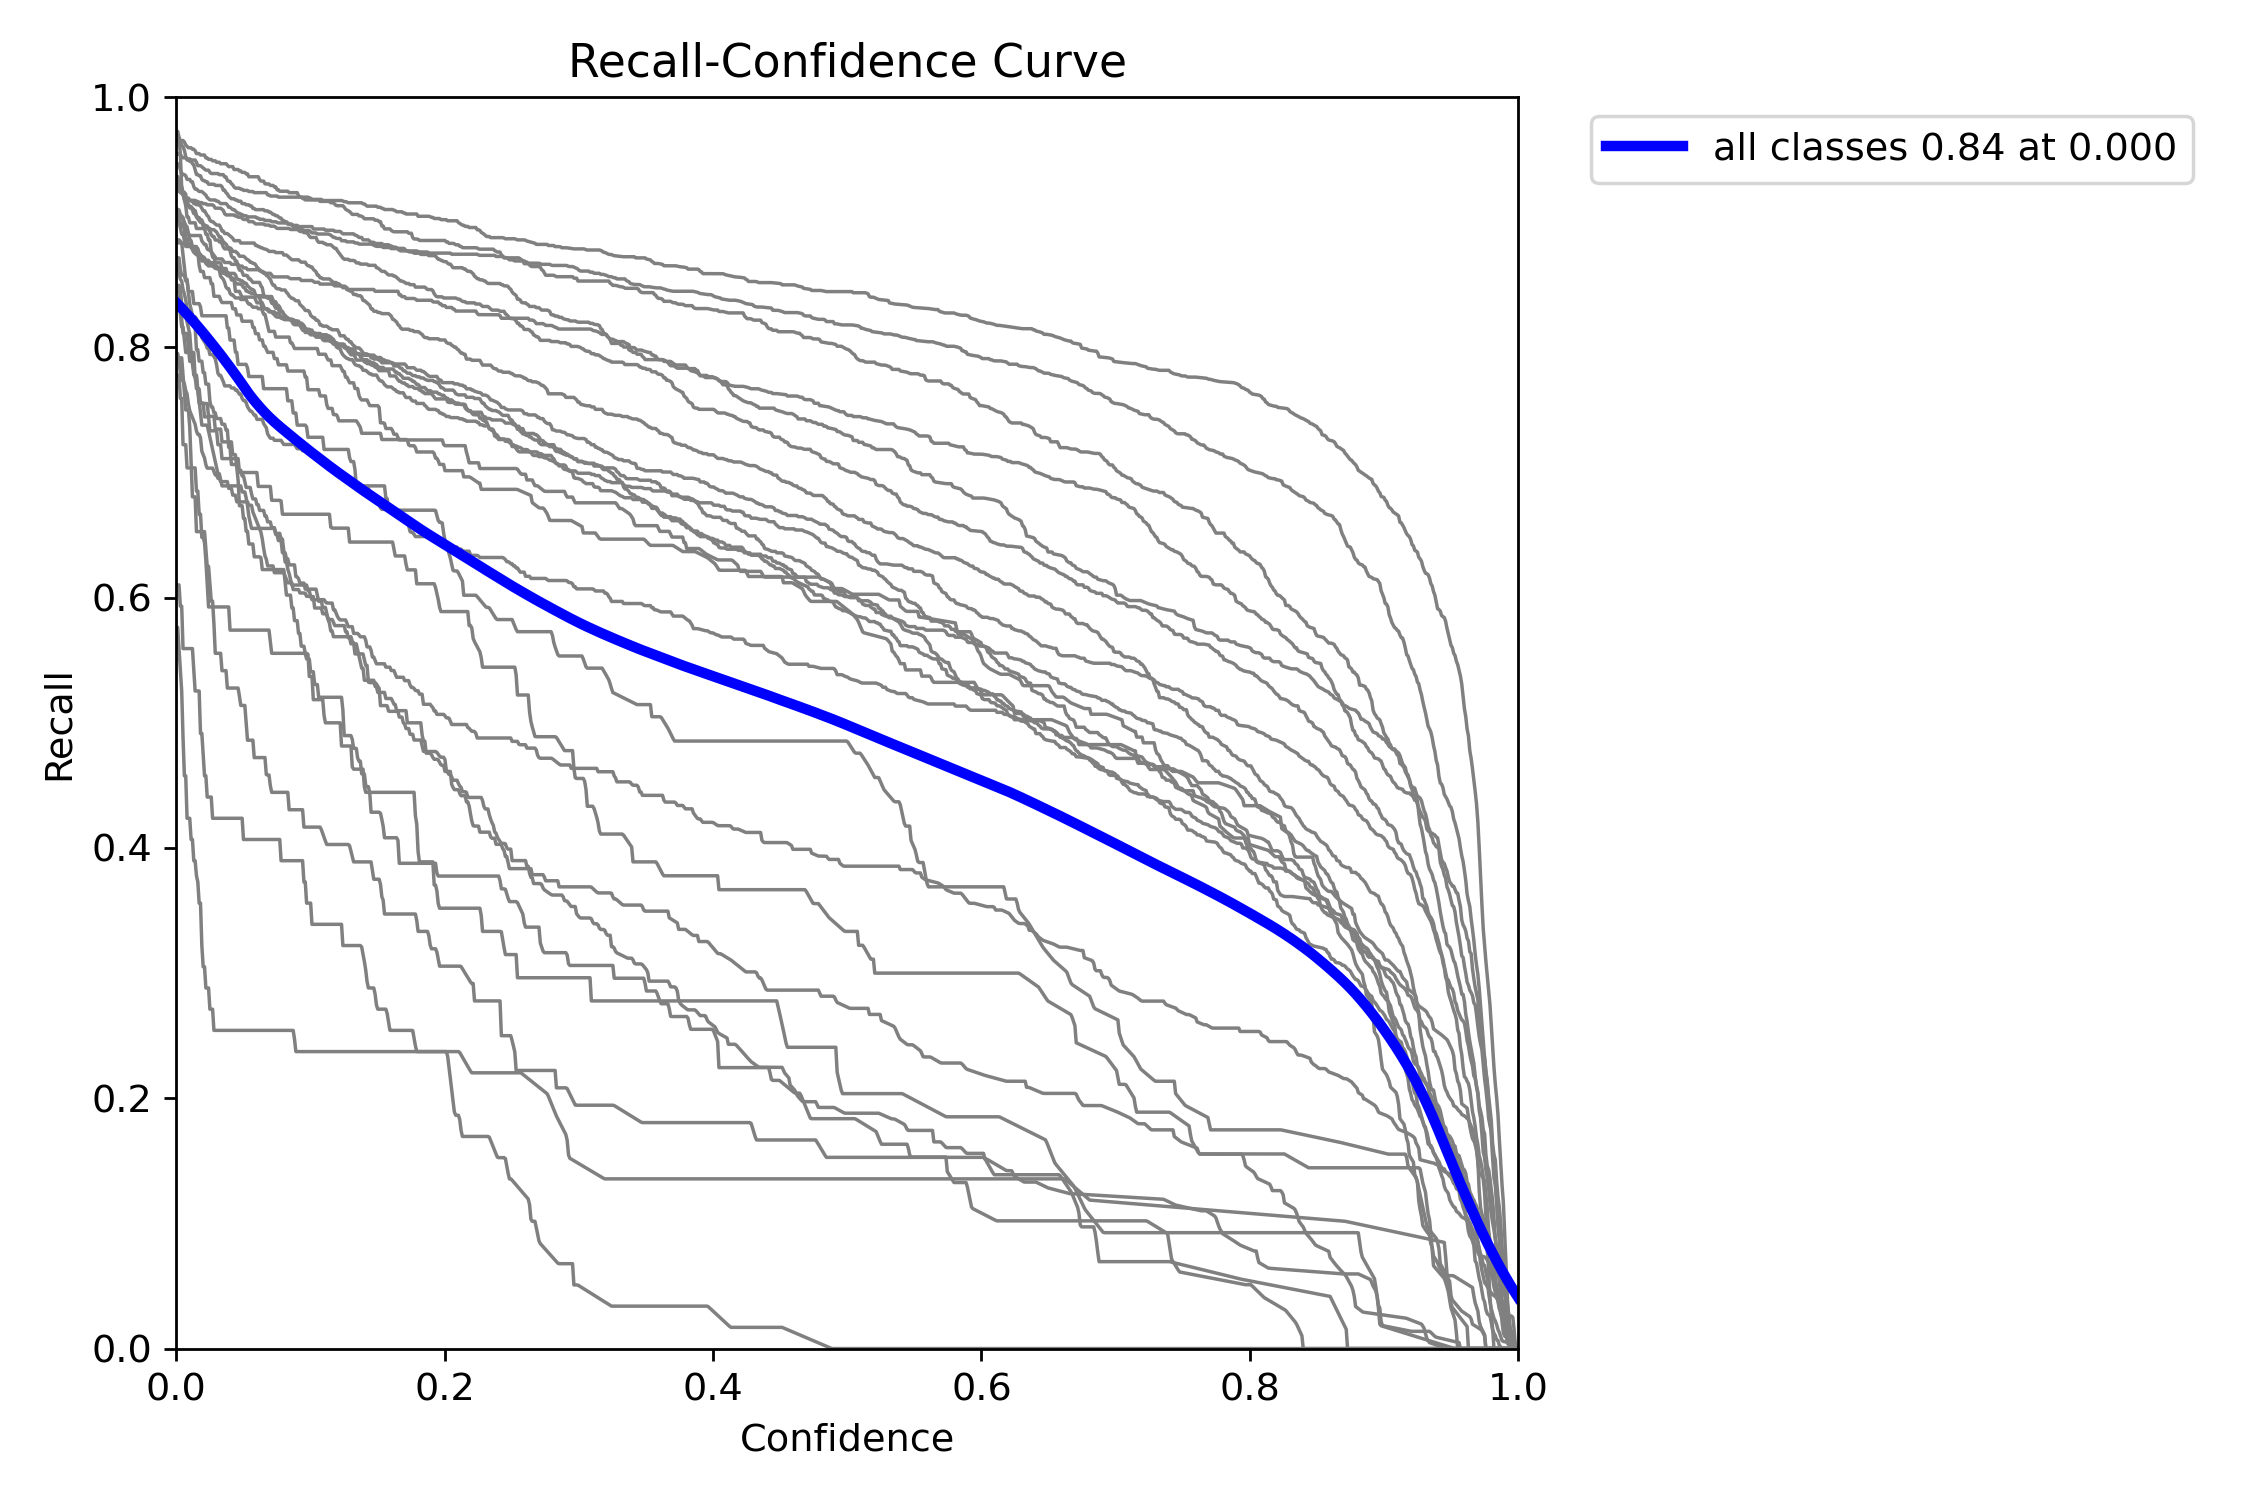

In [19]:
# Recall Curve
Image(filename=str(RESULTS_FOLDER/"BoxR_curve_640.png"))

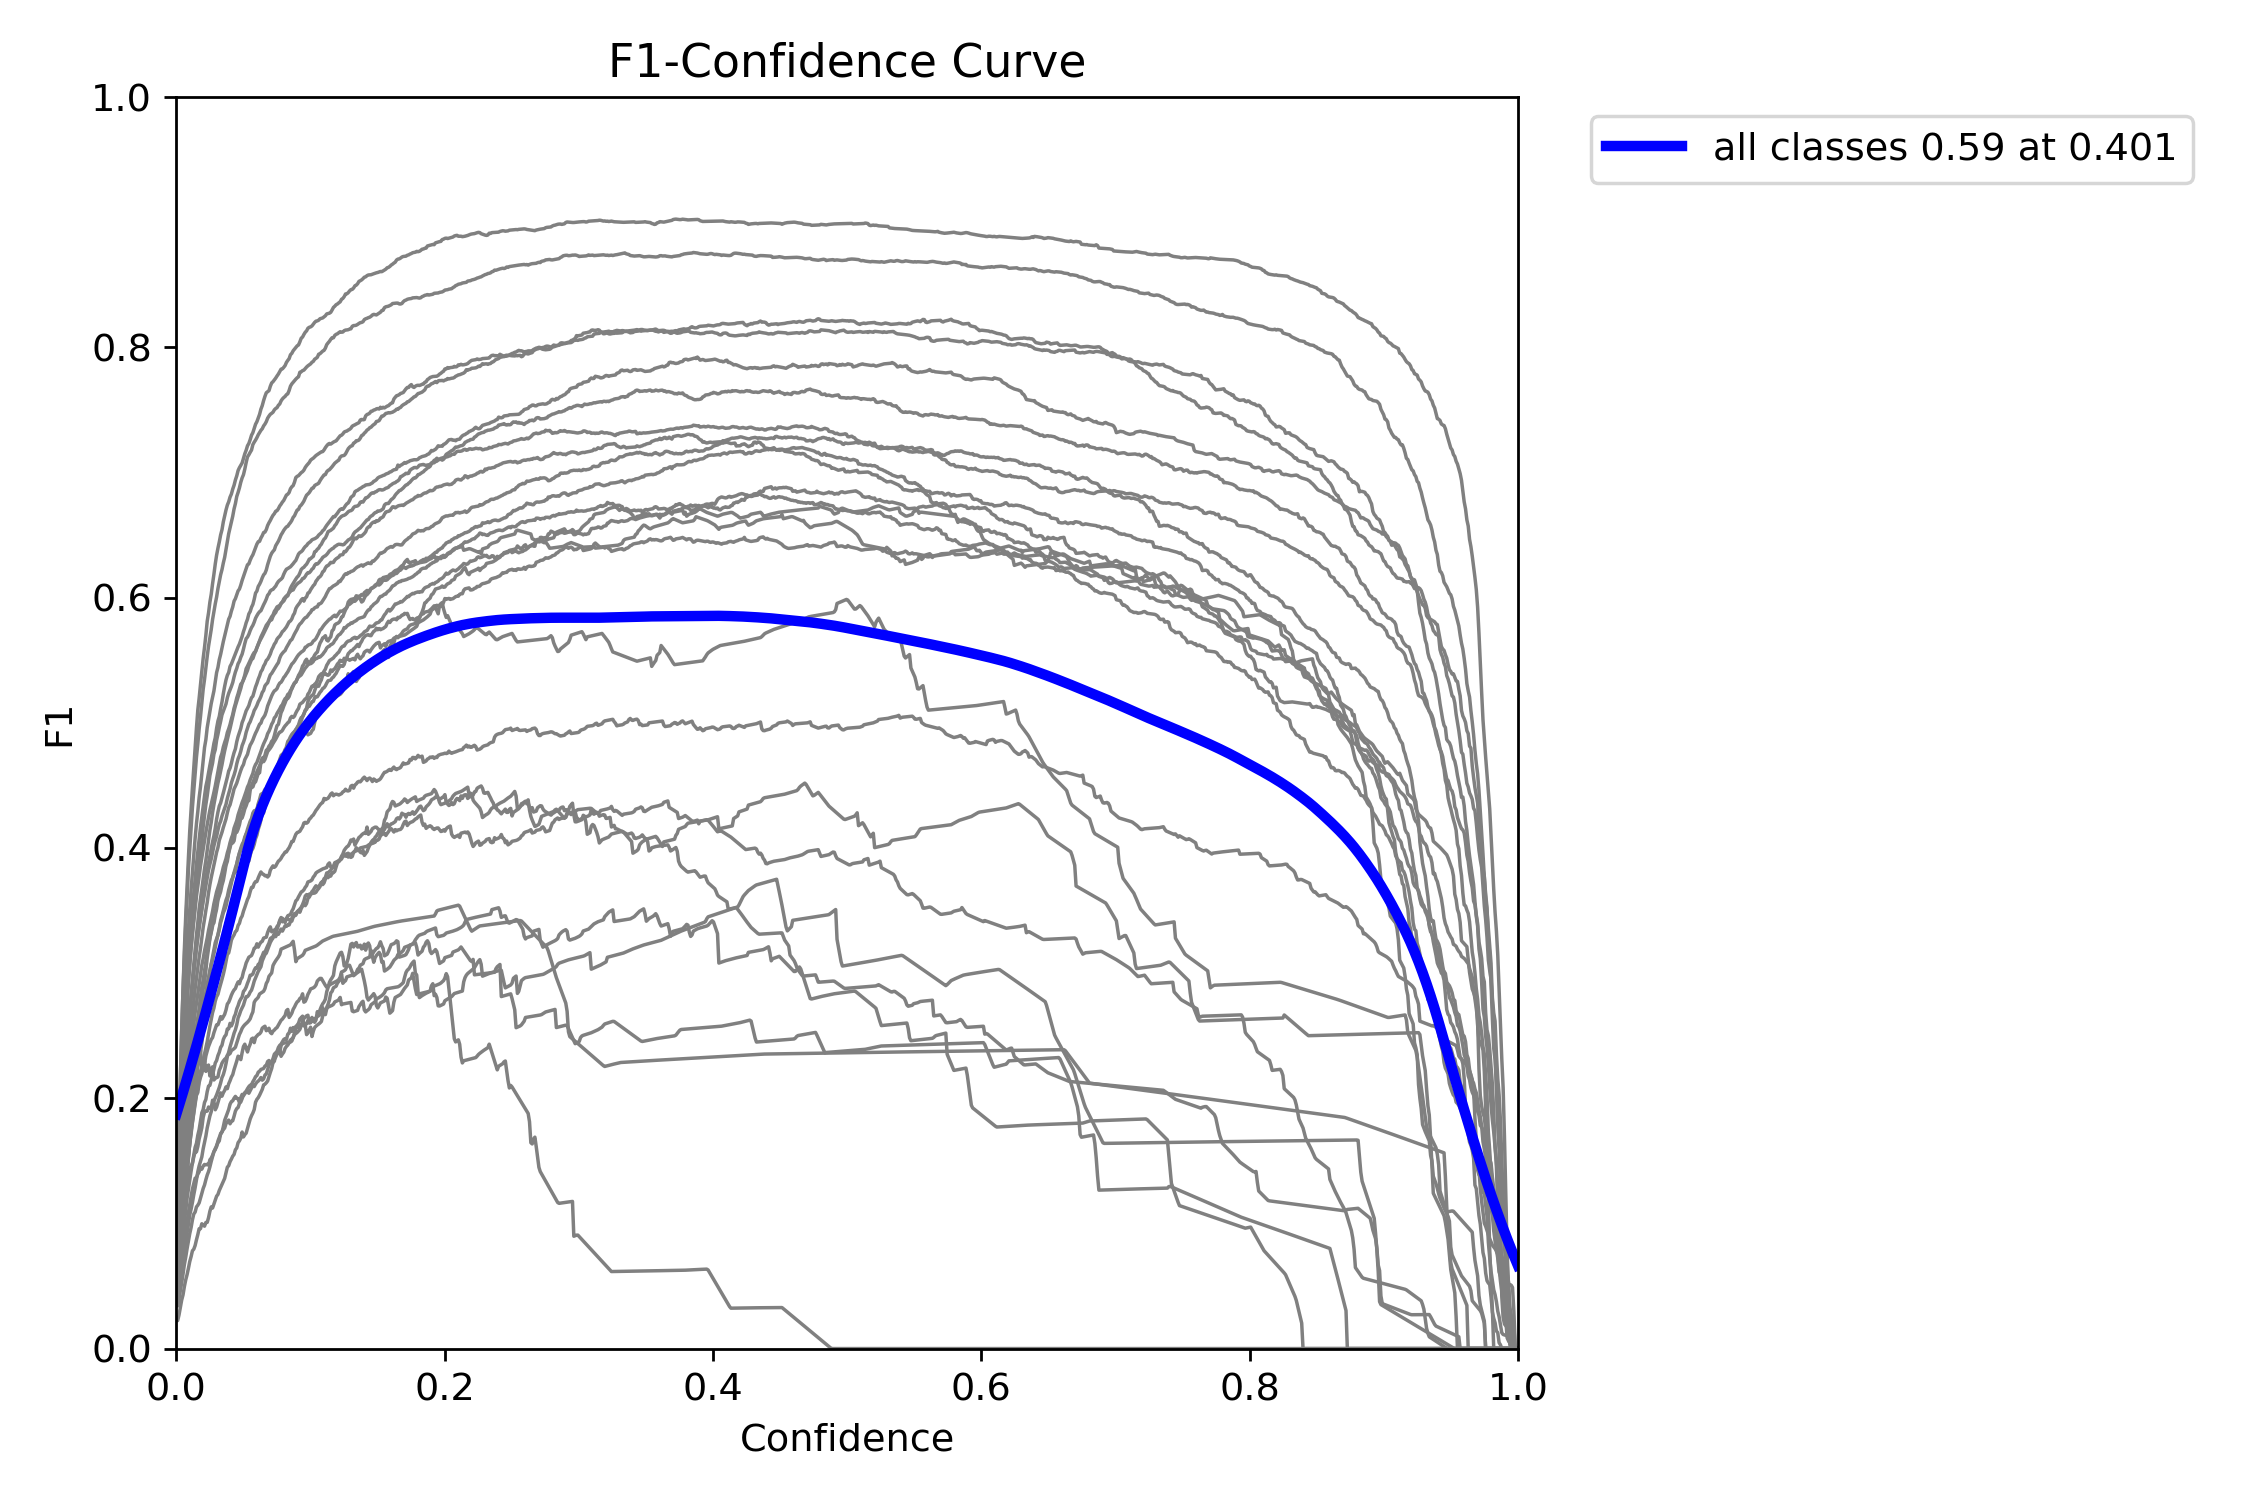

In [20]:
# F1 Curve
Image(filename=str(RESULTS_FOLDER/"BoxF1_curve_640.png"))

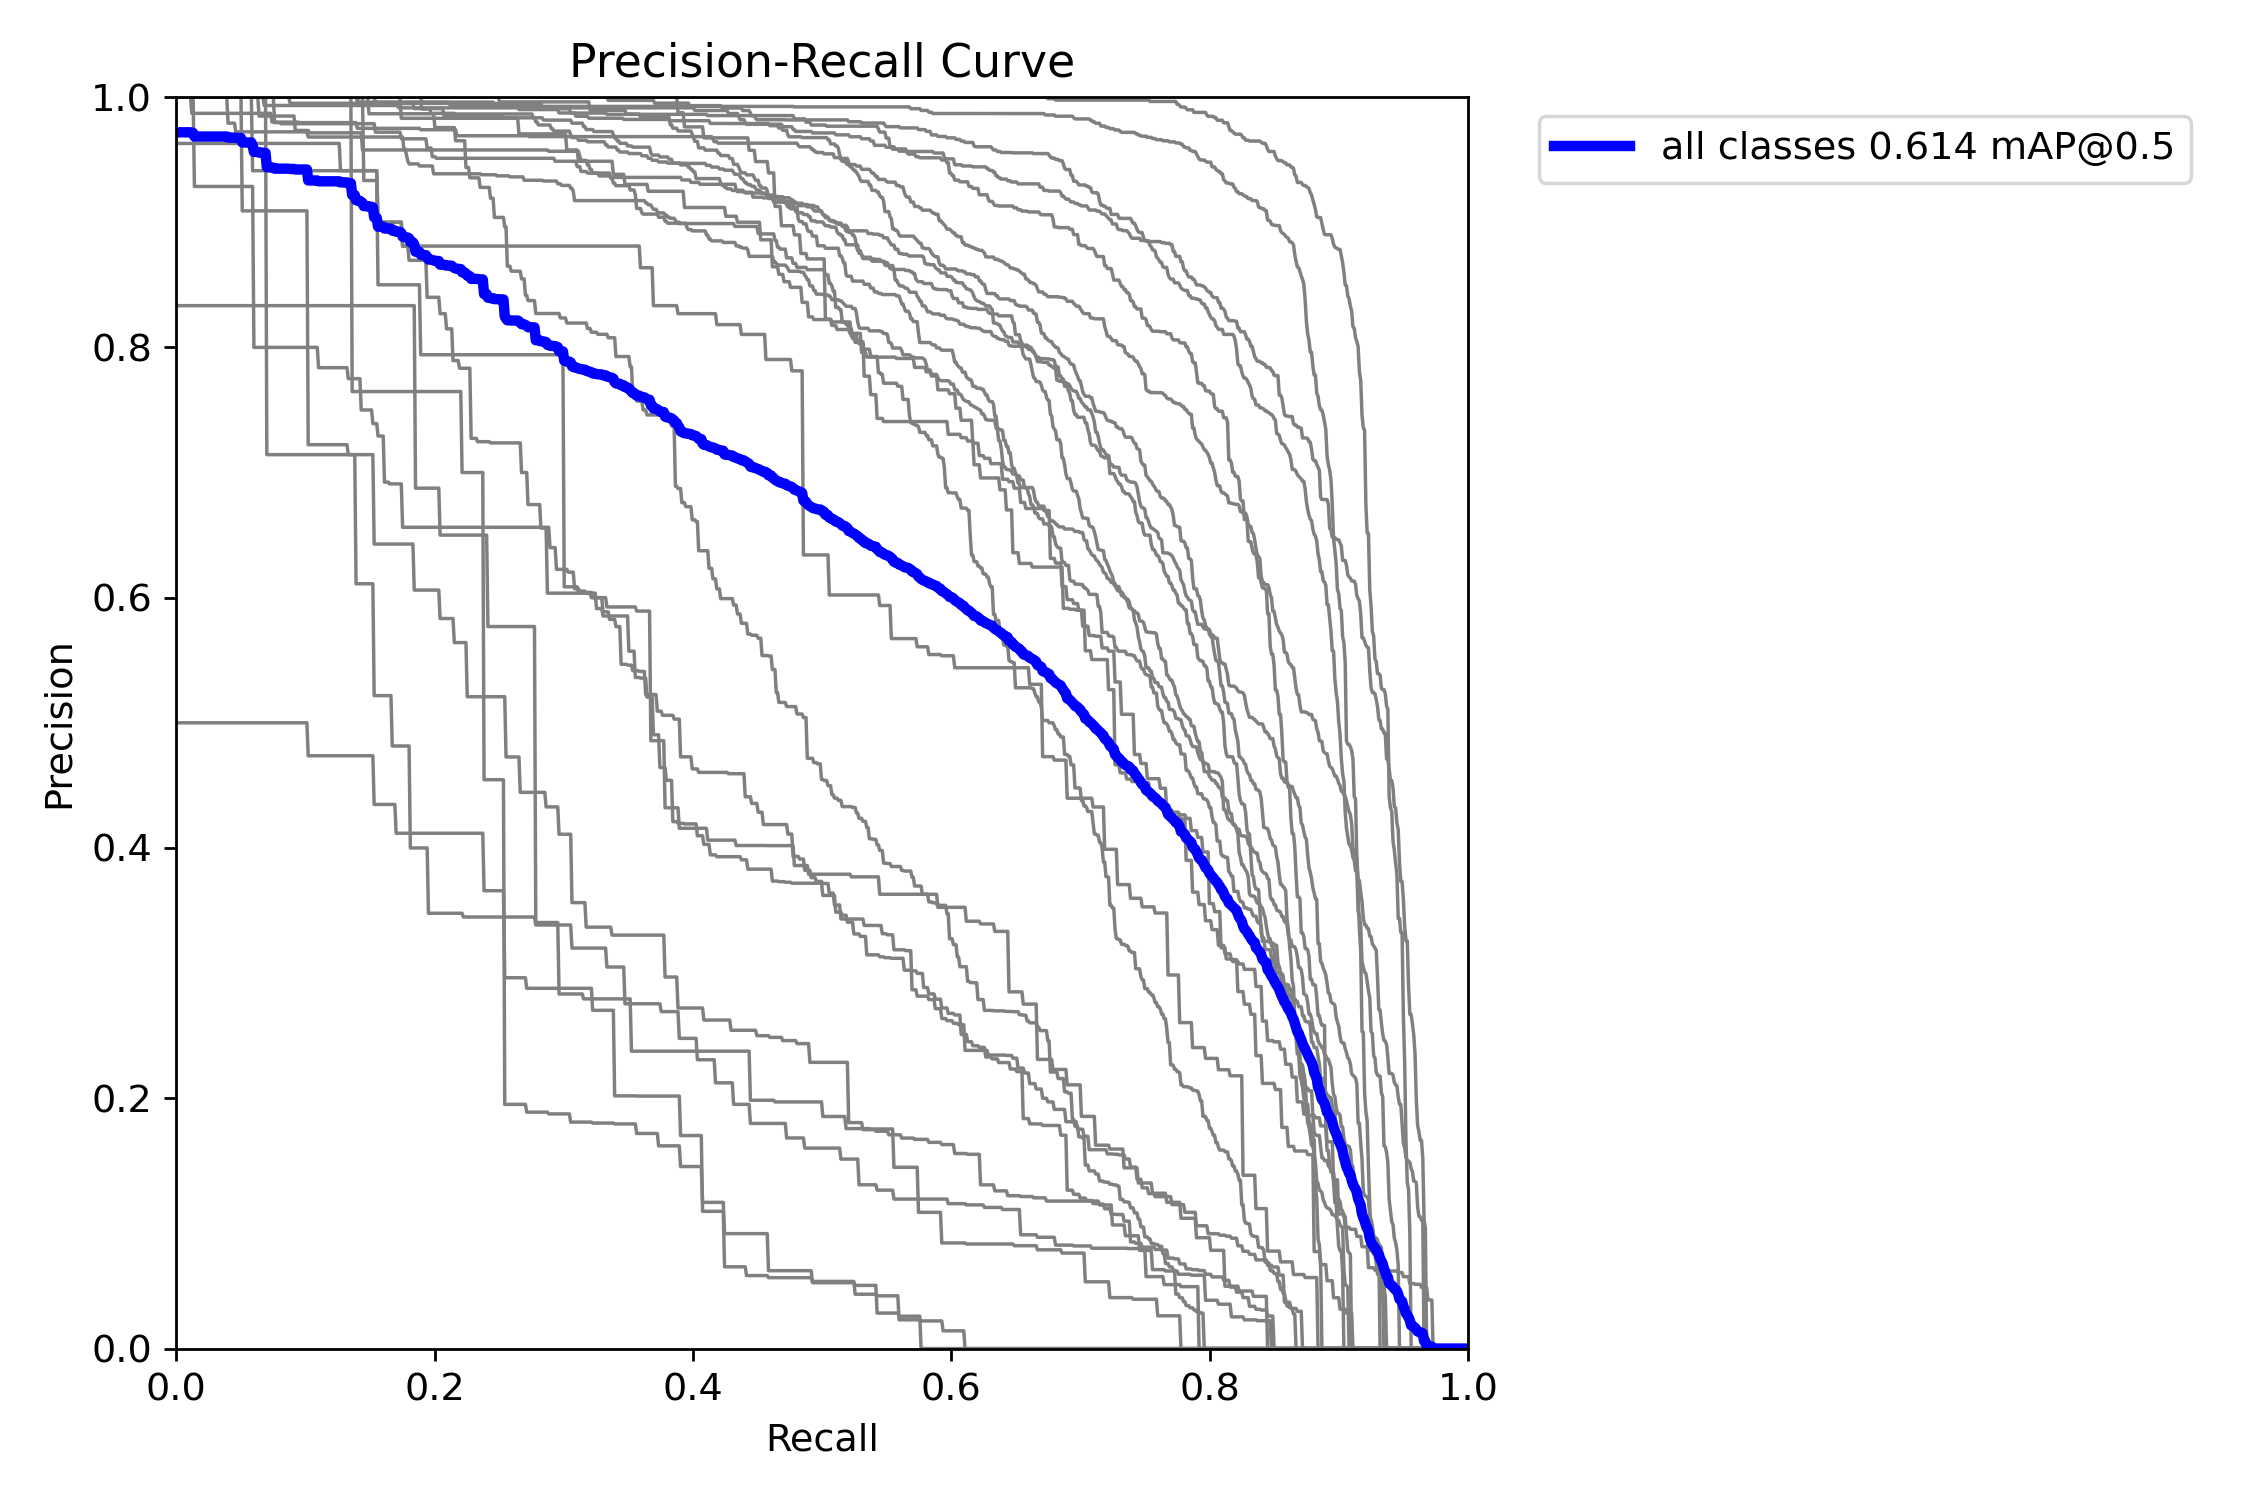

In [21]:
# PR Curve
Image(filename=str(RESULTS_FOLDER/"BoxPR_curve_640.png"))


In [22]:
# To display all at once
from IPython.display import Image, display

display(Image(filename=str(RESULTS_FOLDER/"confusion_matrix_640.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxP_curve_640.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxR_curve_640.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxF1_curve_640.png")))
display(Image(filename=str(RESULTS_FOLDER/"BoxPR_curve_640.png")))

Output hidden; open in https://colab.research.google.com to view.

In [23]:

# COMPLETE TRAINING HISTORY


pd.set_option("display.max_columns", None)

results_df

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,147.711,1.73228,4.06401,1.64964,0.36126,0.10932,0.05901,0.04106,1.47438,3.40676,1.44312,0.000115,0.000115,0.000115
1,2,286.141,1.24858,2.99031,1.31987,0.45564,0.16153,0.12838,0.09416,1.14258,2.75504,1.20643,0.000218,0.000218,0.000218
2,3,424.981,1.06059,2.47442,1.19181,0.47298,0.24057,0.19986,0.15052,1.00104,2.30634,1.10802,0.000310,0.000310,0.000310
3,4,566.114,0.95828,2.17464,1.12244,0.40509,0.28395,0.26863,0.20662,0.87444,2.00832,1.03386,0.000294,0.000294,0.000294
4,5,705.667,0.90584,1.98777,1.08878,0.50494,0.34096,0.32692,0.25958,0.80306,1.78985,0.98833,0.000277,0.000277,0.000277
5,6,847.319,0.84912,1.83465,1.05828,0.53900,0.35427,0.36262,0.29190,0.75030,1.67058,0.96304,0.000260,0.000260,0.000260
6,7,998.238,0.80964,1.73277,1.03741,0.53687,0.38823,0.40315,0.32753,0.72792,1.56034,0.94772,0.000243,0.000243,0.000243
7,8,1143.040,0.78952,1.65006,1.02376,0.60208,0.40086,0.43341,0.35214,0.70553,1.43570,0.93016,0.000225,0.000225,0.000225
8,9,1289.160,0.75943,1.57754,1.01189,0.58009,0.41606,0.44600,0.36334,0.67909,1.41002,0.92490,0.000208,0.000208,0.000208
9,10,1436.960,0.74839,1.52737,1.00549,0.61336,0.43474,0.47371,0.39664,0.64560,1.29227,0.90319,0.000191,0.000191,0.000191


In [24]:

# TRAINING SUMMARY


print("Total Epochs :", len(results_df))

print("Best mAP@0.5 :", results_df["metrics/mAP50(B)"].max())

print("Best Precision :", results_df["metrics/precision(B)"].max())

print("Best Recall :", results_df["metrics/recall(B)"].max())



Total Epochs : 20
Best mAP@0.5 : 0.61475
Best Precision : 0.69604
Best Recall : 0.56697


In [25]:

# SAVE EVALUATION REPORT


report_path = RESULTS_FOLDER / "evaluation_summary_640.txt"

with open(report_path, "w") as file:

    file.write("YOLO MODEL EVALUATION\n")
    file.write("="*50 + "\n\n")

    file.write(f"Best mAP@0.5 : {results_df['metrics/mAP50(B)'].max():.4f}\n")

    file.write(f"Best Precision : {results_df['metrics/precision(B)'].max():.4f}\n")

    file.write(f"Best Recall : {results_df['metrics/recall(B)'].max():.4f}\n")

print("Evaluation report saved successfully.")

Evaluation report saved successfully.


In [26]:
# GENERATED FILES


for file in sorted(RESULTS_FOLDER.iterdir()):

    print(file.name)

BoxF1_curve_640.png
BoxPR_curve_640.png
BoxP_curve_640.png
BoxR_curve_640.png
confusion_matrix_640.png
confusion_matrix_normalized_640.png
evaluation_summary_640.txt
imgsz640_args.yaml
labels_640.jpg
results_640.csv
results_640.png
train_batch0_640.jpg
train_batch1_640.jpg
train_batch2910_640.jpg
train_batch2911_640.jpg
train_batch2912_640.jpg
train_batch2_640.jpg
val_batch0_labels_640.jpg
val_batch0_pred_640.jpg
val_batch1_labels_640.jpg
val_batch1_pred_640.jpg
val_batch2_labels_640.jpg
val_batch2_pred_640.jpg
weights_imgsz_640


In [ ]:
!pip install ImageHash
from PIL import Image
import imagehash
from pathlib import Path

val_dir = DATASET_PATH / "images" / "val"

hashes = {}

duplicates = []

for img_path in val_dir.glob("*"):
    h = imagehash.average_hash(Image.open(img_path))

    if h in hashes:
        duplicates.append((hashes[h], img_path.name))
    else:
        hashes[h] = img_path.name

print("Duplicate pairs:", len(duplicates))

duplicates[:20]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 7.1 MB/s eta 0:00:00
Duplicate pairs: 403


[('warehouse_001033.png', 'warehouse_000964.png'),
 ('warehouse_002499.png', 'warehouse_002495.png'),
 ('warehouse_012526.png', 'warehouse_012539.png'),
 ('warehouse_001033.png', 'warehouse_000957.png'),
 ('warehouse_013074.png', 'warehouse_013075.png'),
 ('warehouse_012526.png', 'warehouse_012547.png'),
 ('warehouse_000302.png', 'warehouse_000307.png'),
 ('warehouse_011980.png', 'warehouse_011983.png'),
 ('warehouse_010626.png', 'warehouse_010627.png'),
 ('warehouse_012526.png', 'warehouse_012523.png'),
 ('warehouse_001266.png', 'warehouse_001269.png'),
 ('warehouse_001266.png', 'warehouse_001265.png'),
 ('warehouse_010175.png', 'warehouse_010183.png'),
 ('warehouse_011080.png', 'warehouse_011095.png'),
 ('warehouse_001033.png', 'warehouse_000992.png'),
 ('warehouse_001033.png', 'warehouse_001023.png'),
 ('warehouse_000365.png', 'warehouse_000363.png'),
 ('warehouse_002832.png', 'warehouse_002826.png'),
 ('warehouse_001033.png', 'warehouse_000936.png'),
 ('warehouse_000753.png', 'ware

In [ ]:
from pathlib import Path
import hashlib

val_dir = DATASET_PATH / "images" / "val"

hashes = {}
duplicates = []

for img_path in val_dir.glob("*"):
    with open(img_path, "rb") as f:
        md5 = hashlib.md5(f.read()).hexdigest()

    if md5 in hashes:
        duplicates.append((hashes[md5], img_path.name))
    else:
        hashes[md5] = img_path.name

print("Validation Images :", len(list(val_dir.glob("*"))))
print("Exact Duplicate Images :", len(duplicates))

if duplicates:
    print(duplicates[:20])
else:
    print("No exact duplicate images.")

Validation Images : 1125
Exact Duplicate Images : 0
No exact duplicate images.
